In [4]:
# Importar librerias
import pandas as pd
import yfinance as yf
import mplfinance as mpf
import matplotlib.pyplot as plt


In [10]:
# Indicador Media Movil Exponencial (EMA) Exponential Moving Average
def Media_Movil_Exponencial(df: pd.DataFrame, logitud: int = 26, columna: str = "Close") -> pd.DataFrame:
    return df[columna].ewm(span=logitud, min_periods=logitud, adjust=False).mean()

# df = df[columna]
#     EMA = df.ewm(span=longitud, min_periods=longitud, adjust=False).mean()
#     EMA.name = "EMA"

In [9]:
# Descragar los datos
df = yf.download("MSFT", start="2023-01-01", end="2024-01-01", interval="1d", multi_level_index=False) 

[*********************100%***********************]  1 of 1 completed


In [11]:
# Calcular Indicador 
ema_12 = Media_Movil_Exponencial(df, 12, "Close")
ema_26 = Media_Movil_Exponencial(df, 26, "Close")

In [12]:
ema_12

Date
2023-01-03           NaN
2023-01-04           NaN
2023-01-05           NaN
2023-01-06           NaN
2023-01-09           NaN
                 ...    
2023-12-22    369.003653
2023-12-26    369.331549
2023-12-27    369.519086
2023-12-28    369.862167
2023-12-29    370.268288
Name: Close, Length: 250, dtype: float64

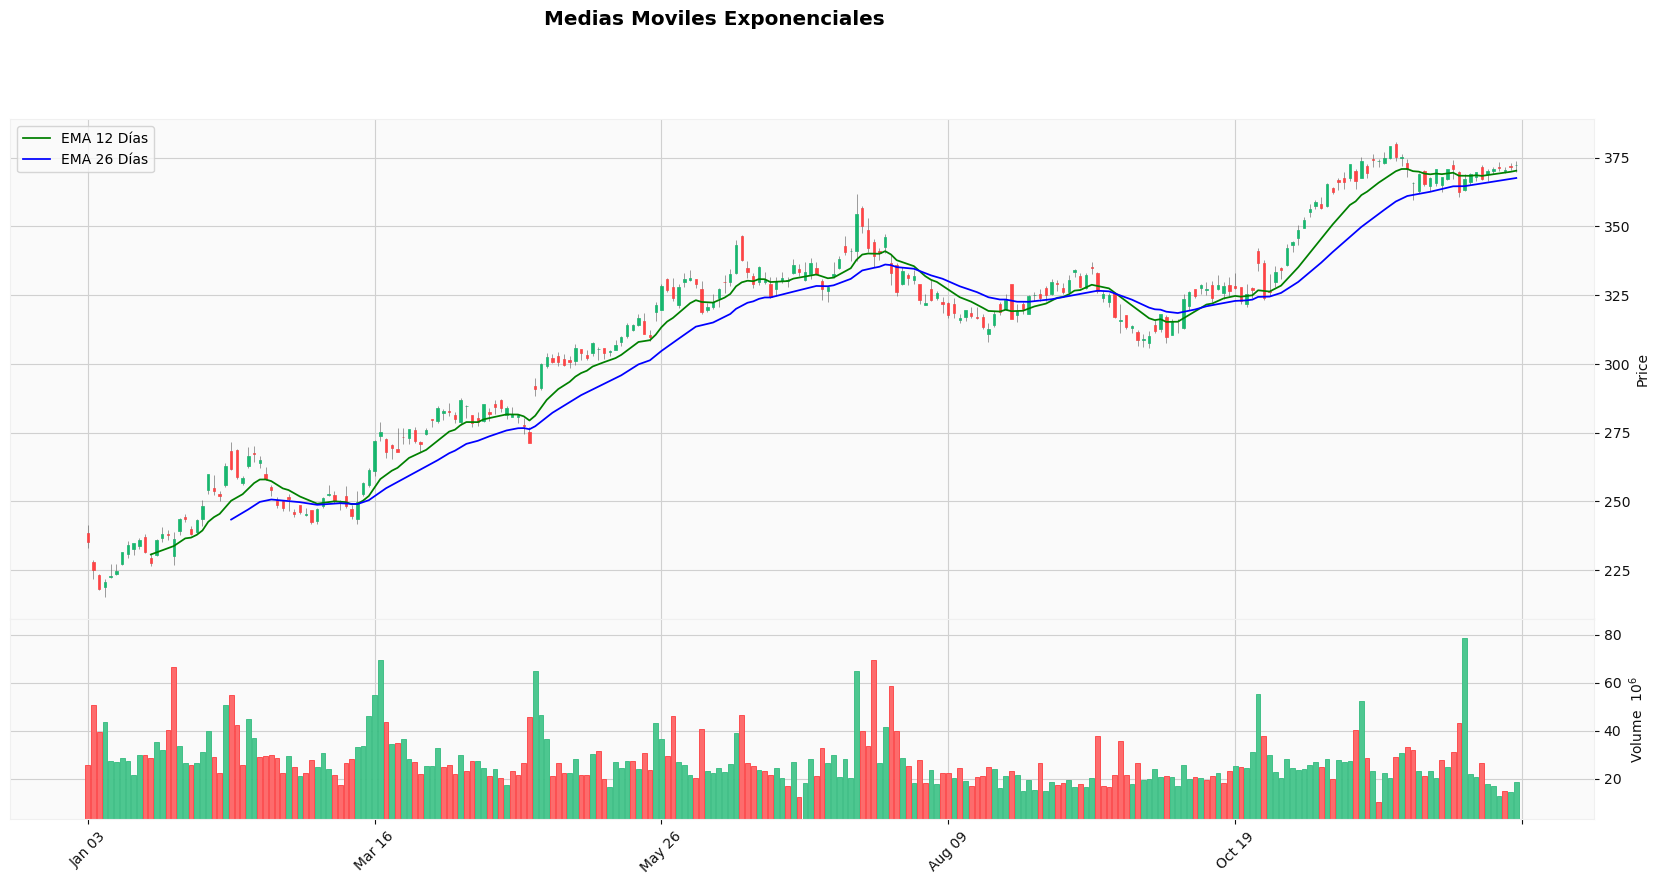

In [13]:
# Graficar
ema_plots = [
    
    mpf.make_addplot(ema_12, label="EMA 12 Días", color="green", type="line"),
    mpf.make_addplot(ema_26, label="EMA 26 Días", color="blue", type="line")
    
    ]

mpf.plot(df, type="candle", style="yahoo", volume=True, figsize=(22,10), addplot=ema_plots, figscale=3.0, title="Medias Moviles Exponenciales" )